<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Phased_Arrays_versus_Nanoscale_Metasurface_Array_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [1]:
!uv pip install -q cupy-cuda12x graphviz pandas matplotlib && uv pip install -q phidl || true

CuPy GPU: Tesla T4


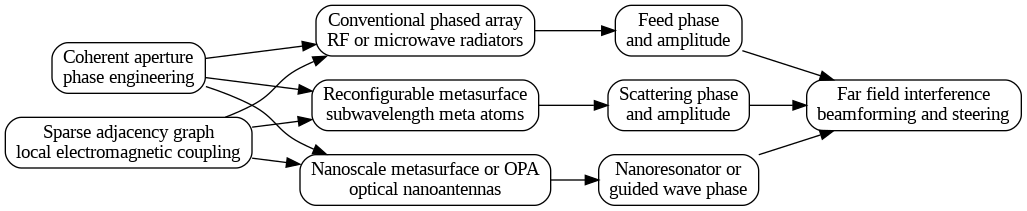


Running Conventional phased array ...

Running Reconfigurable metasurface ...

Running Nanoscale reconfigurable metasurface ...


,Architecture,Frequency,Wavelength,Pitch,Pitch / λ,Array,Elements,Aperture width,Directed graph edges,Coupling bound,Iterations,Residual,Peak θ,Peak φ,Steering error,Phase RMS
0,Conventional phased array,10.000 GHz,29.979 mm,14.990 mm,0.50,17 × 17,289,239.834 mm,2112,0.188000,7,4.61e-08,28.02°,25.20°,0.096°,0.767°
1,Reconfigurable metasurface,60.000 GHz,4.997 mm,1.249 mm,0.25,33 × 33,1089,39.972 mm,8320,0.374893,14,5.47e-08,28.02°,25.20°,0.096°,1.781°
2,Nanoscale reconfigurable metasurface,193.414 THz,1.550 µm,465.000 nm,0.30,28 × 28,784,12.555 µm,5940,0.325102,12,4.36e-08,28.02°,25.20°,0.096°,1.360°


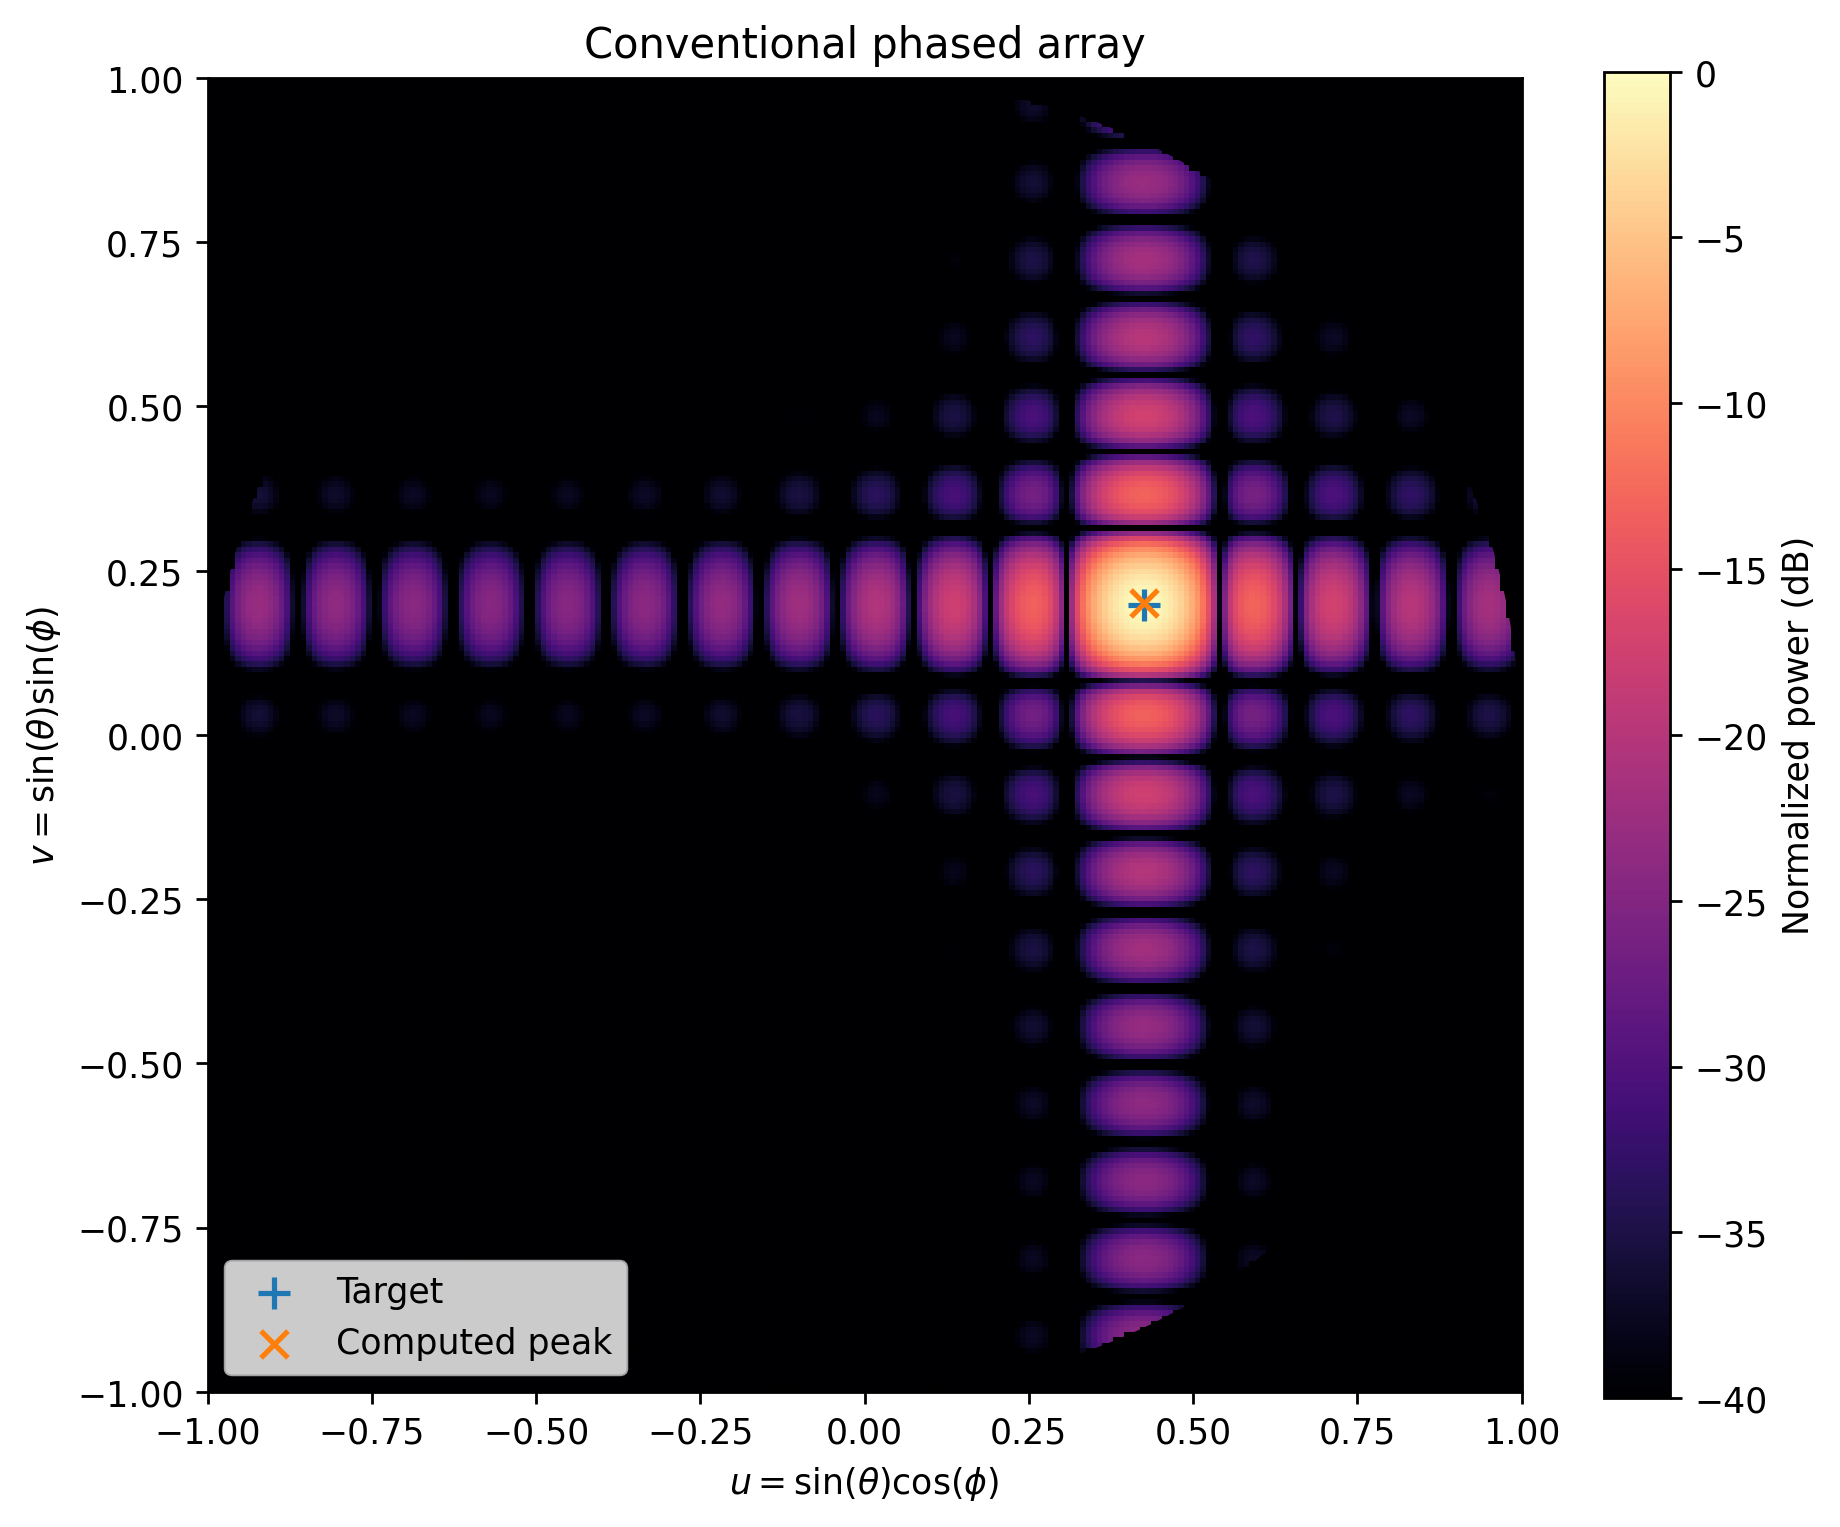

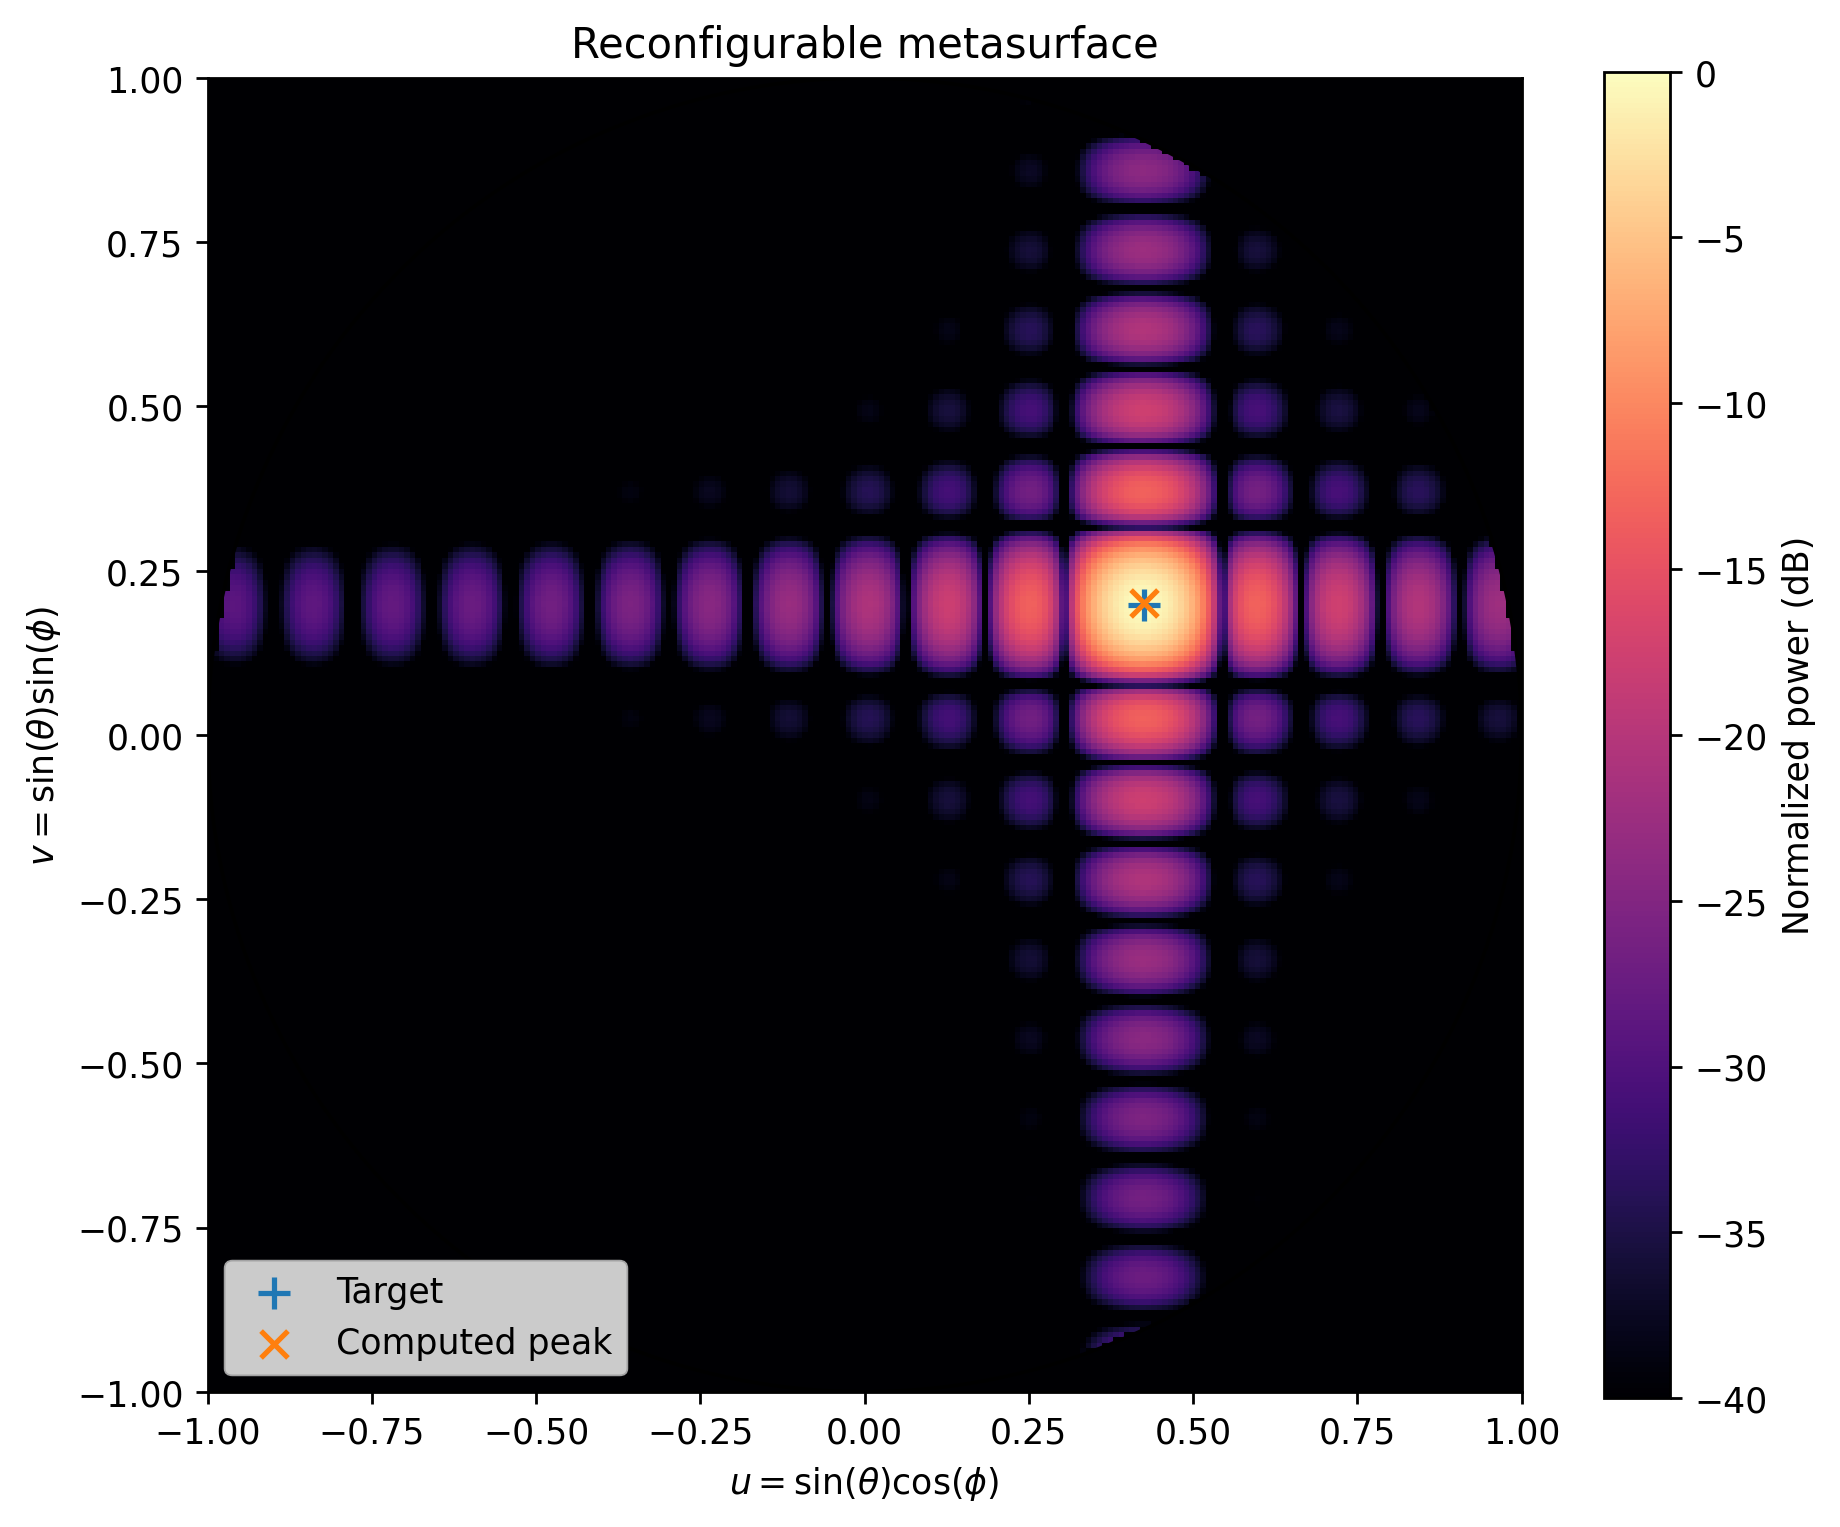

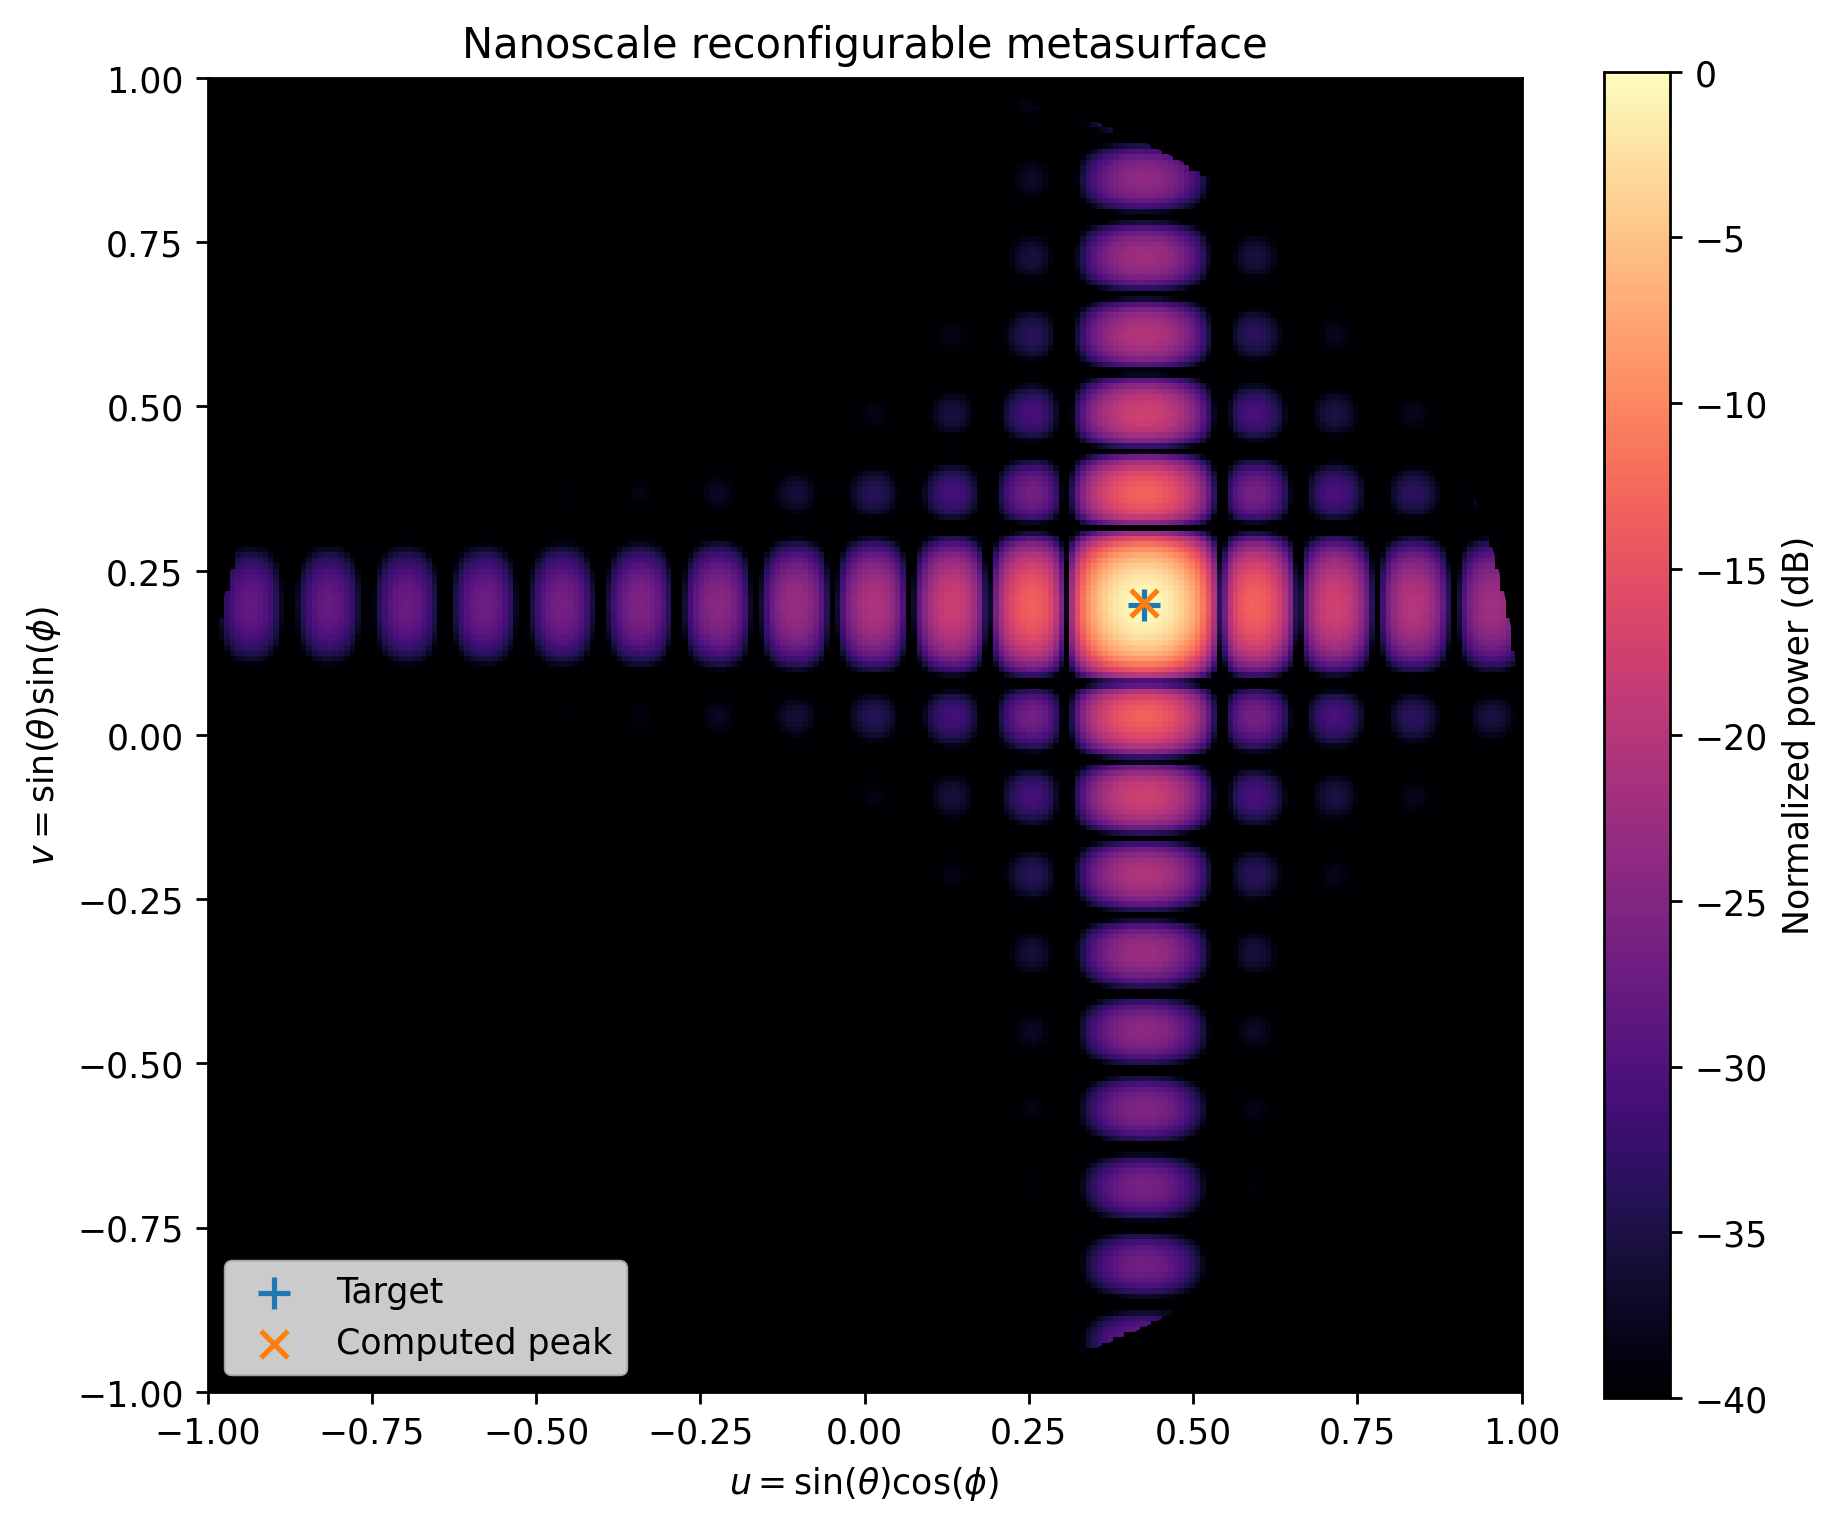

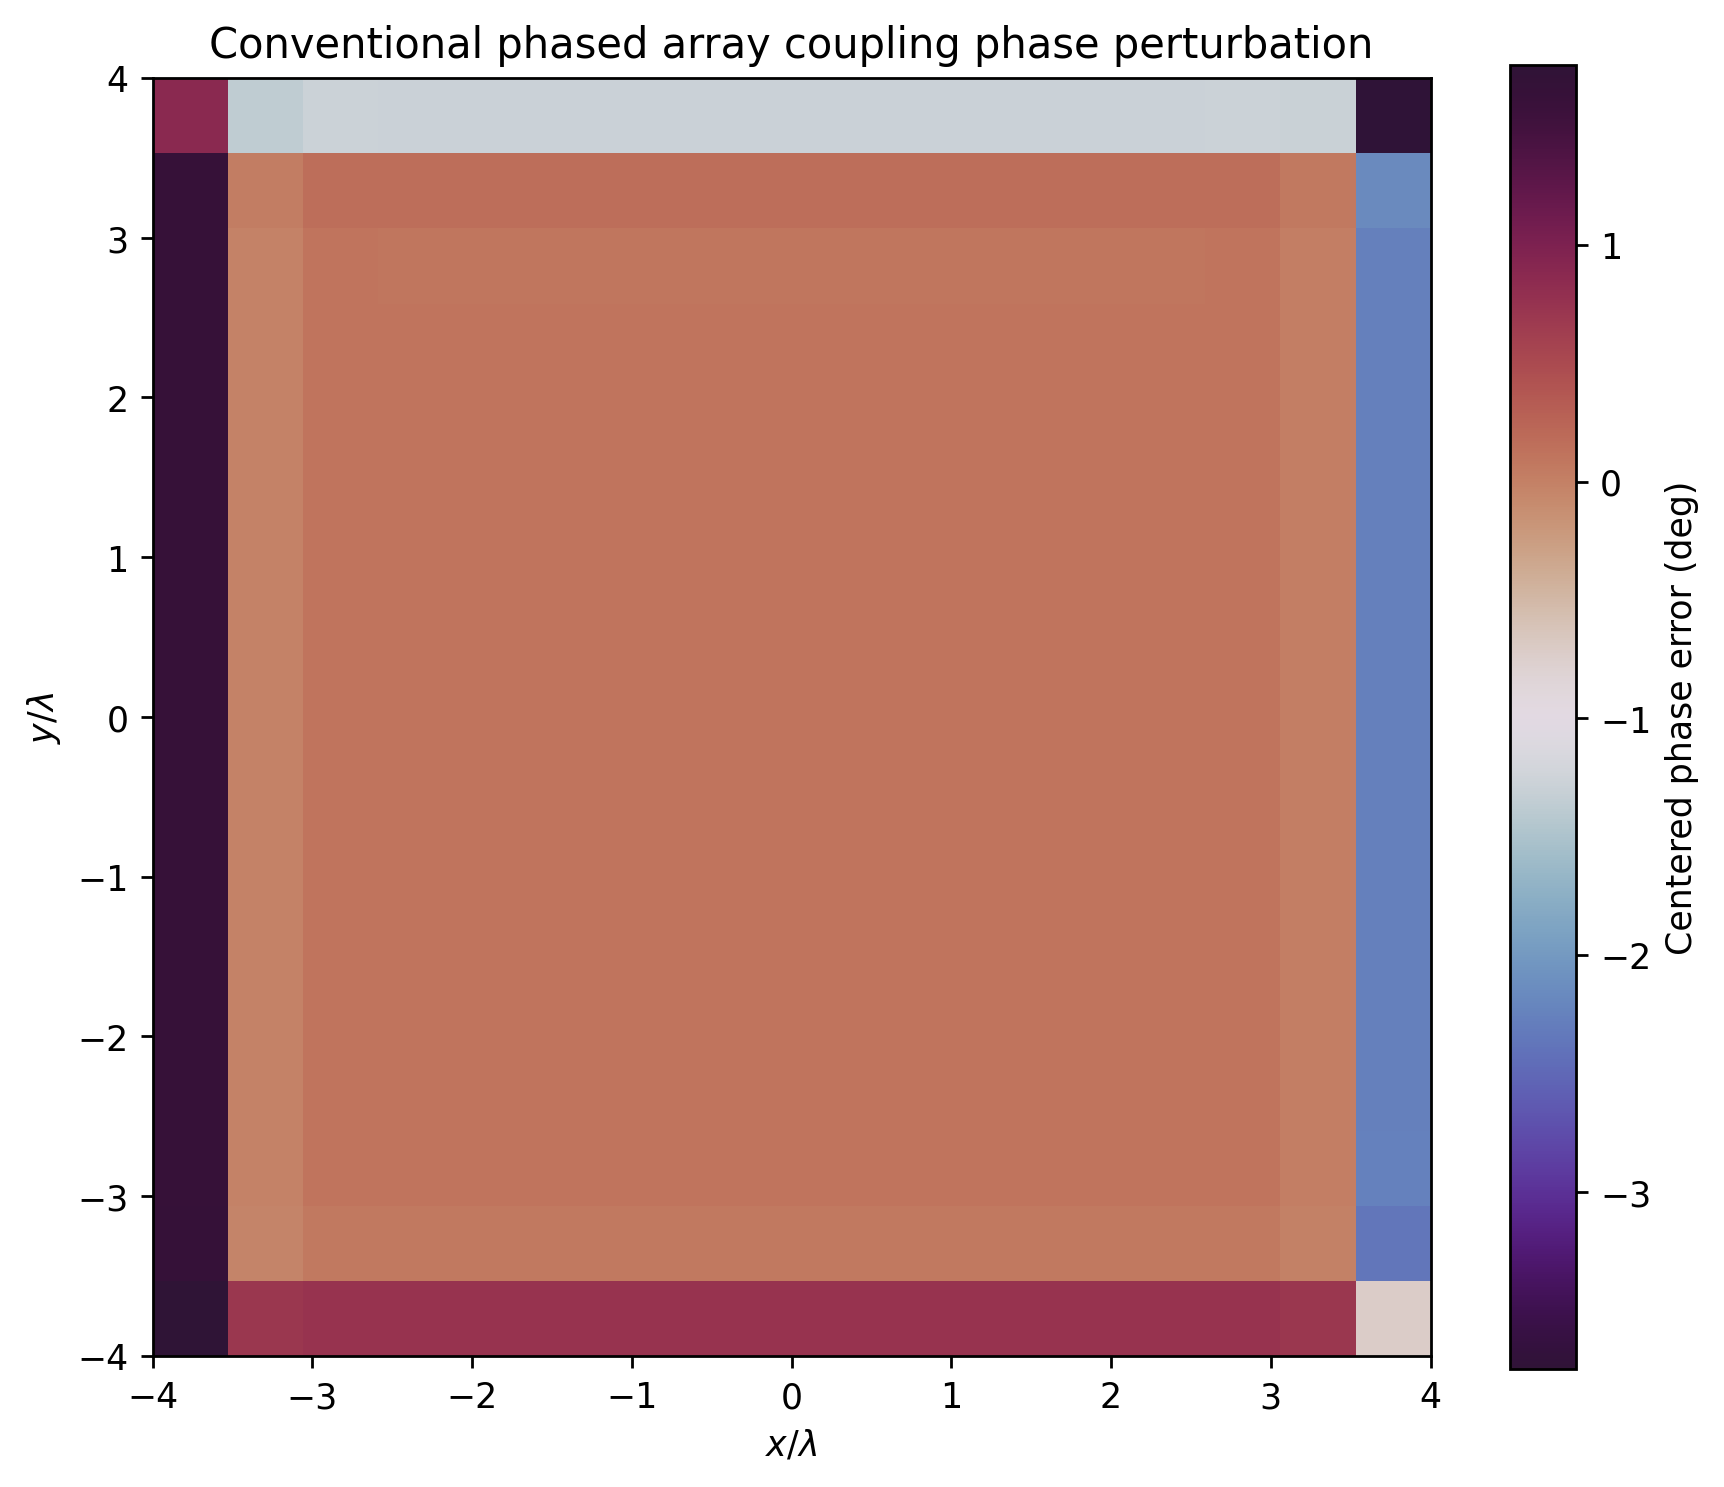

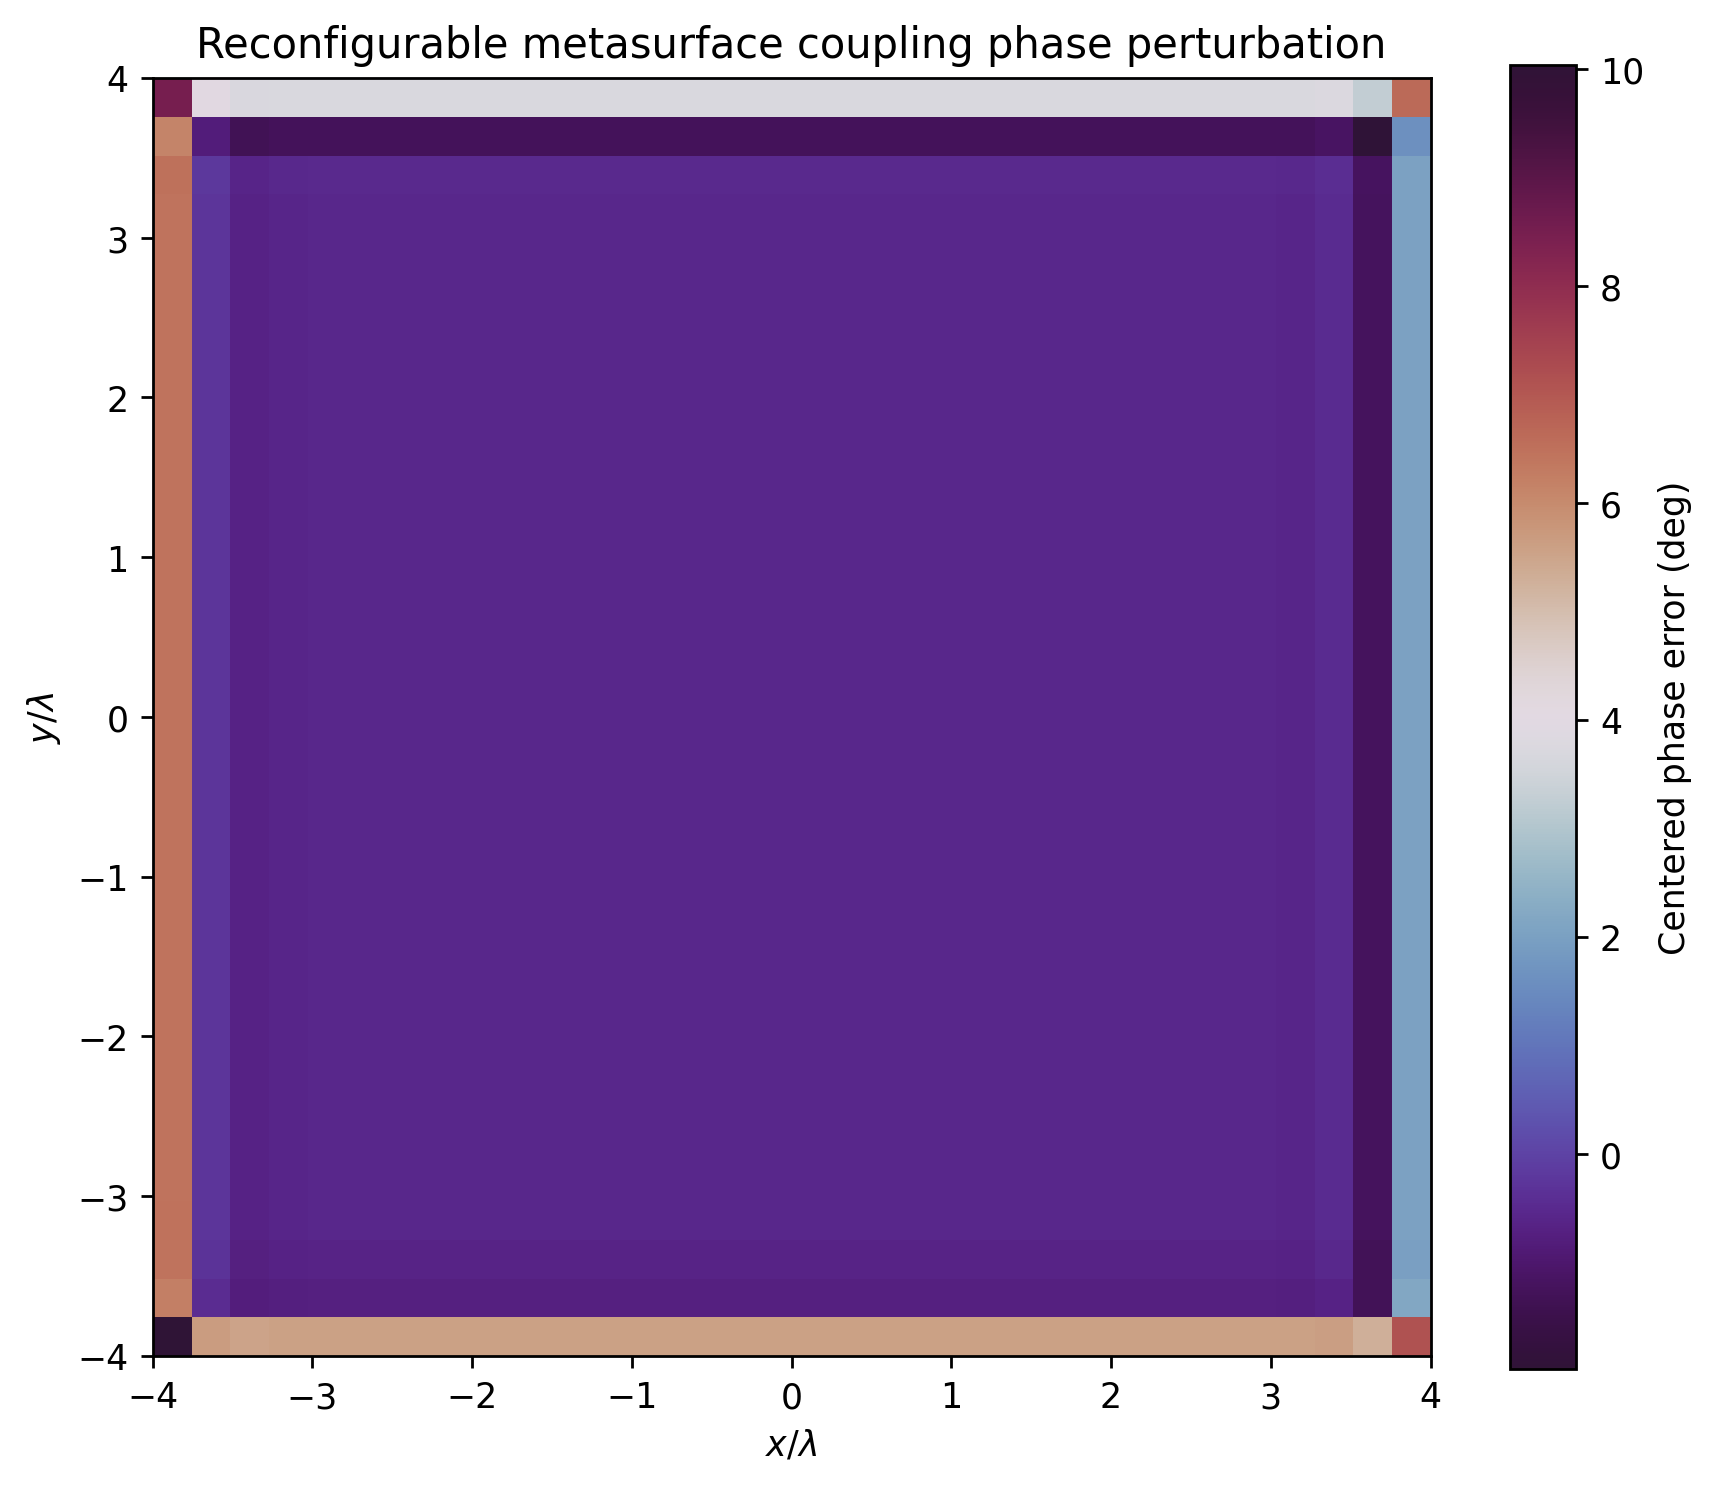

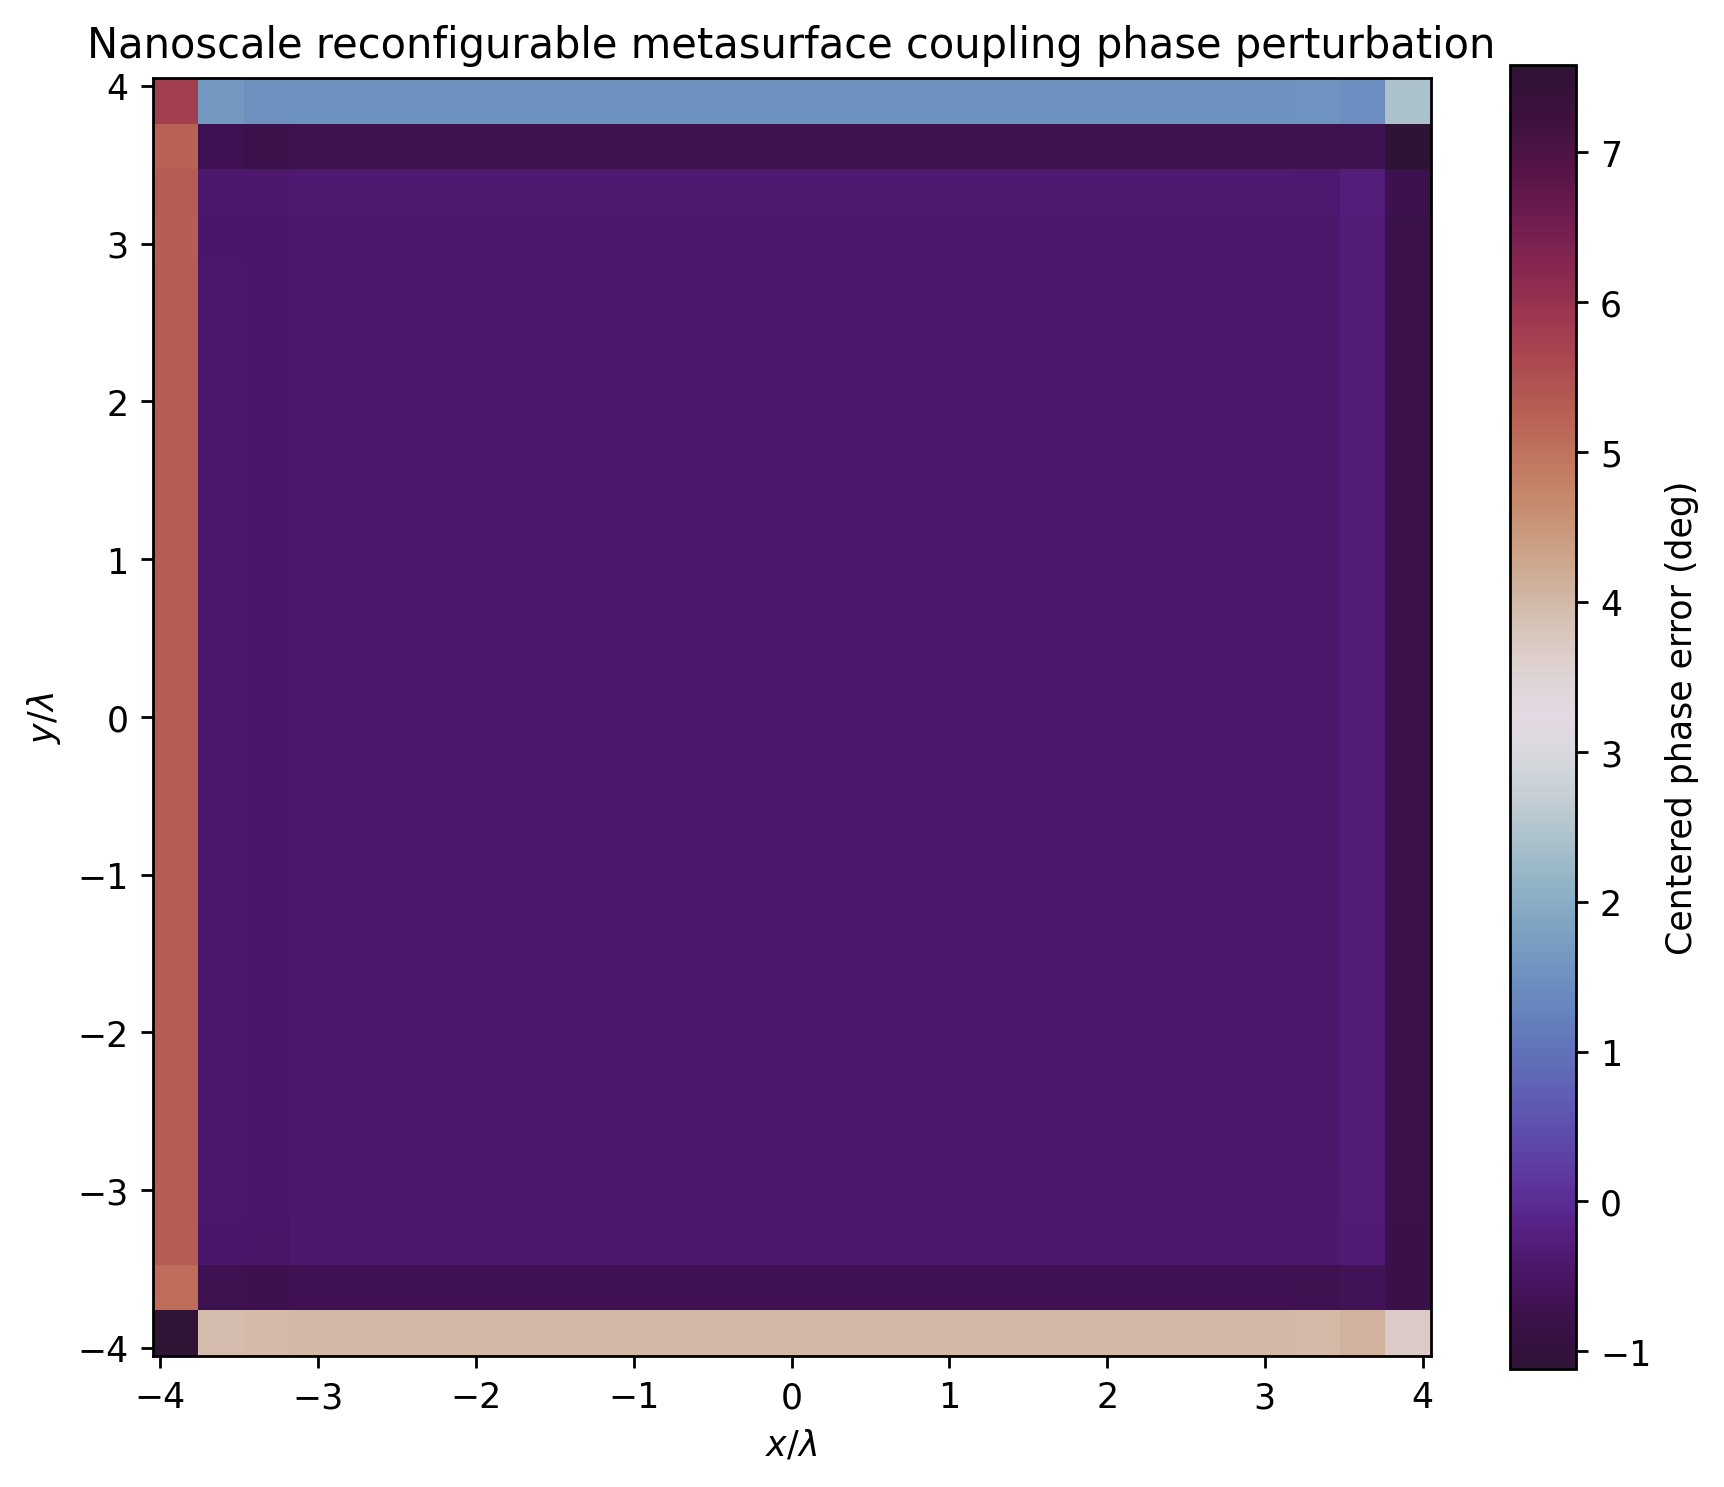

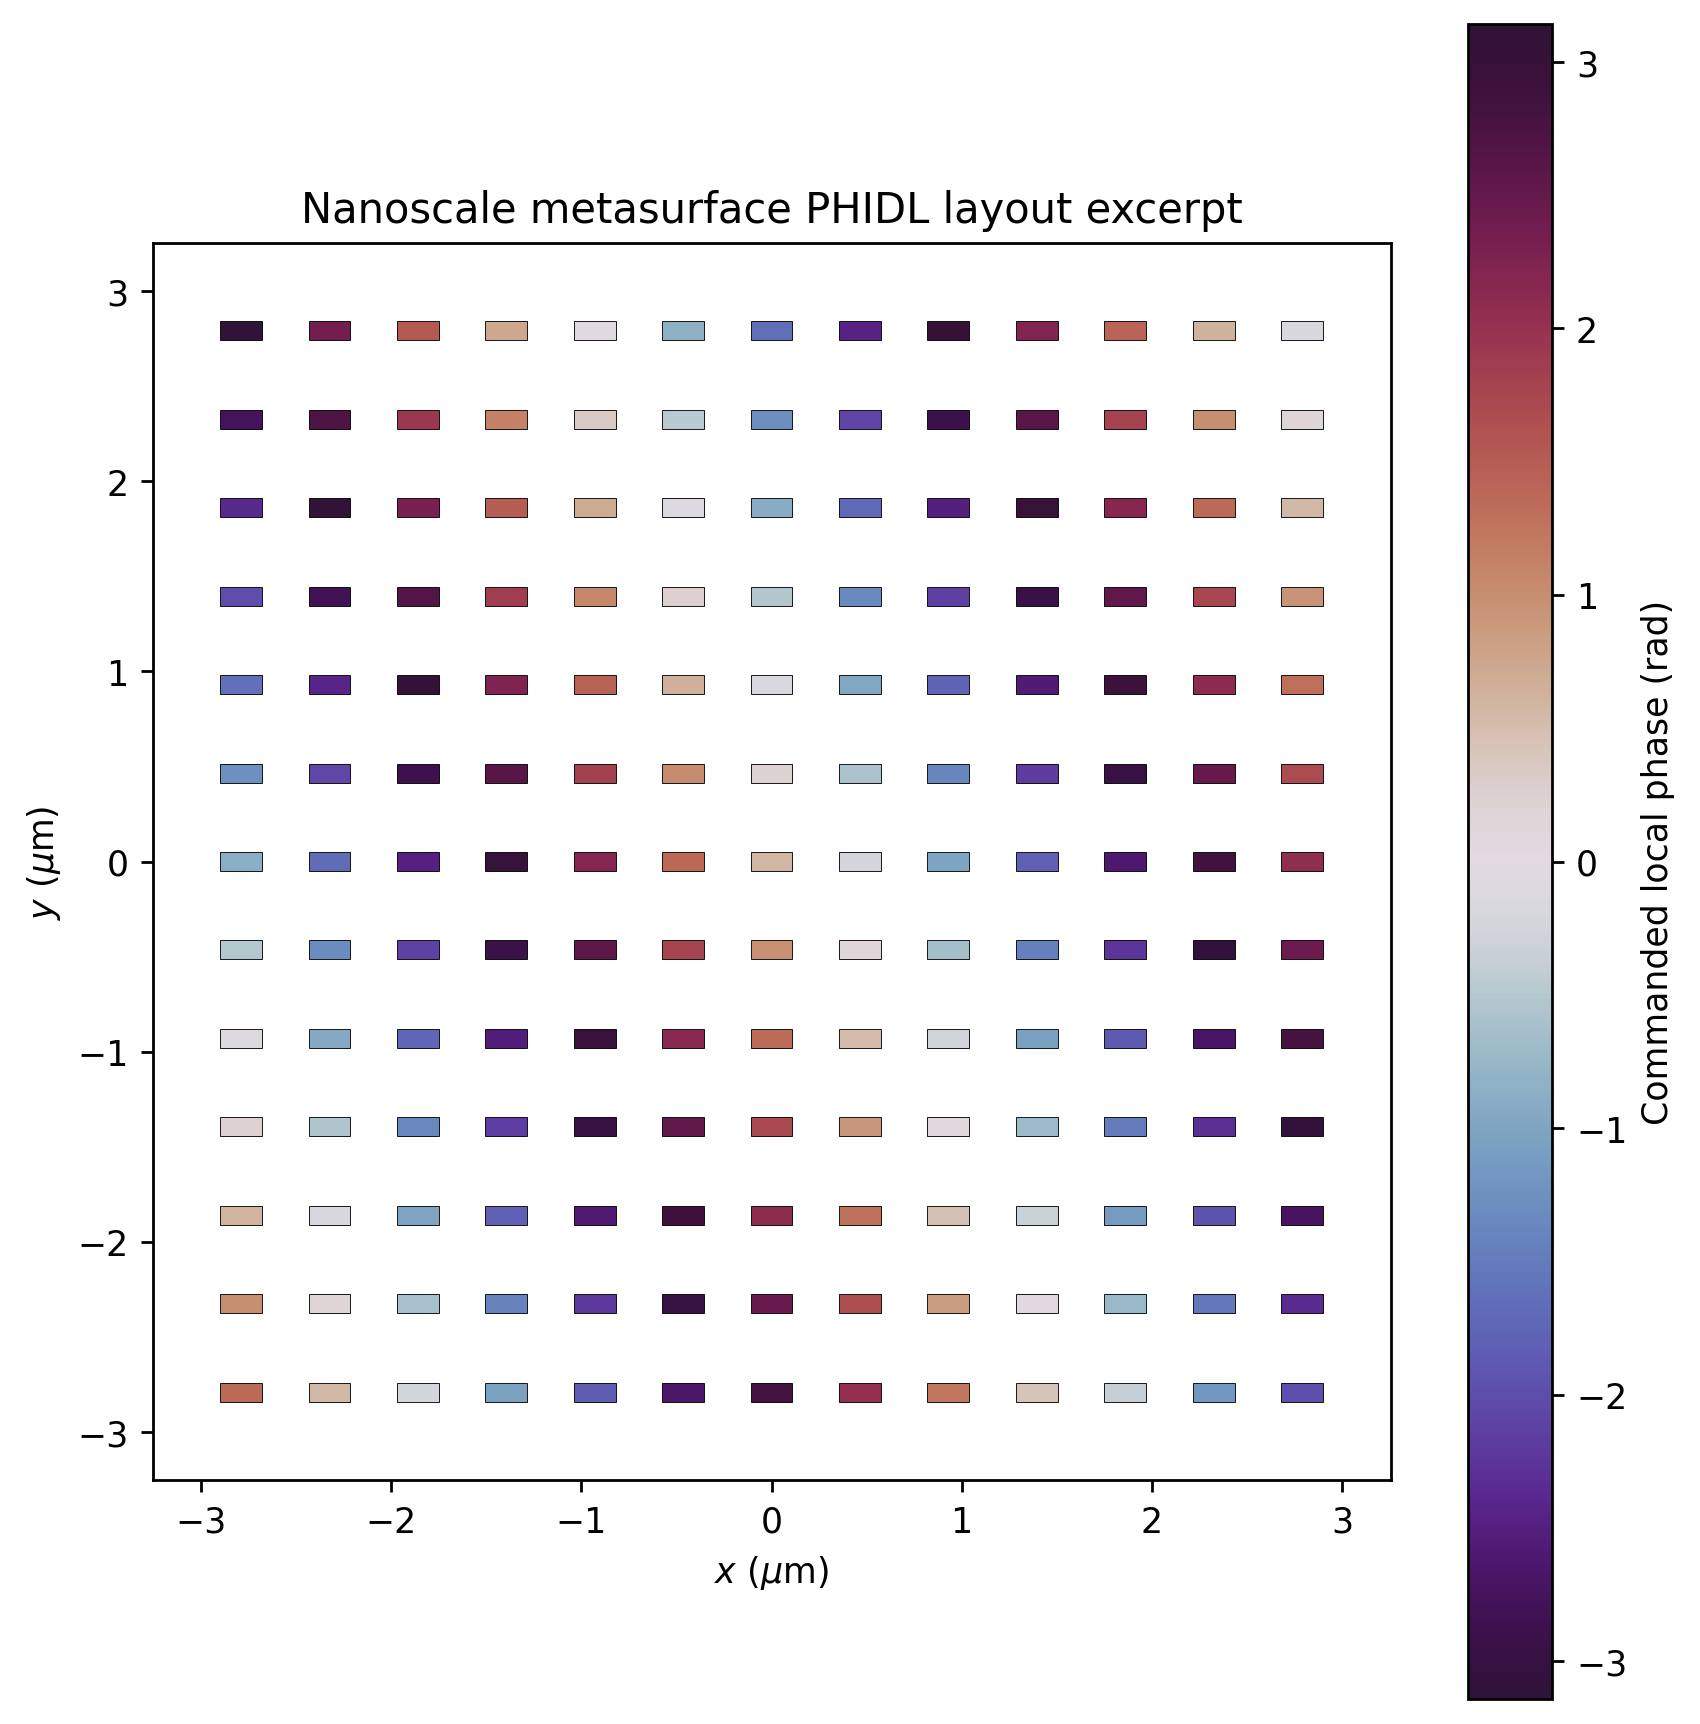

In [2]:
"""Compare phased, metasurface, and nanoscale beamforming on a GPU."""

# ---------------------------------------------------
# CONTROL KNOBS
# ---------------------------------------------------

APERTURE_WIDTH_LAMBDA = 8.0

TARGET_THETA_DEG = 28.0
TARGET_PHI_DEG = 25.0

U_LIMIT = 1.0
FAR_FIELD_SAMPLES = 241
FAR_FIELD_CHUNK = 4096
POWER_FLOOR_DB = -40.0

# Dimensionless coupling surrogate.
# Replace graph edge coefficients with extracted EM coupling data
# for a device specific calculation.
BASE_COUPLING_GAIN = 0.10
COUPLING_DECAY_LAMBDA = 0.60
COUPLING_DISTANCE_POWER = 1.0
COUPLING_NEIGHBORS = 8

MAX_COUPLING_ITERATIONS = 300
COUPLING_TOLERANCE = 1.0e-7
COUPLING_RELAXATION = 1.0

# 0 gives a pure array factor.
# Positive values add a cos(theta)^p planar element factor.
ELEMENT_FACTOR_POWER = 0.0

USE_PHASE_QUANTIZATION = False

PHASE_BITS_BY_ARCHITECTURE = {
    "Conventional phased array": 6,
    "Reconfigurable metasurface": 3,
    "Nanoscale reconfigurable metasurface": 4,
}

PHASE_NOISE_STD_DEG = 0.0
RANDOM_SEED = 7

PLOT_FAR_FIELD_HEATMAPS = True
PLOT_PHASE_ERROR_HEATMAPS = True
RENDER_GRAPHVIZ_MAP = True
RENDER_PHIDL_NANO_PREVIEW = True

NANO_PREVIEW_CELLS_PER_AXIS = 13
NANO_METAATOM_LENGTH_UM = 0.22
NANO_METAATOM_WIDTH_UM = 0.10

C0_M_PER_S = 299_792_458.0

# Frequencies here are representative numerical examples.
# The beamforming calculation itself uses wavelength normalized geometry.
ARCHITECTURES = {
    "Conventional phased array": {
        "frequency_hz": 10.0e9,
        "pitch_lambda": 0.50,
    },
    "Reconfigurable metasurface": {
        "frequency_hz": 60.0e9,
        "pitch_lambda": 0.25,
    },
    "Nanoscale reconfigurable metasurface": {
        "frequency_hz": C0_M_PER_S / 1.55e-6,
        "pitch_lambda": 0.30,
    },
}


# ---------------------------------------------------
# IMPORTS
# ---------------------------------------------------

import math
from dataclasses import dataclass

import cupy as cp
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from cupyx.scipy import sparse as cpsparse
from graphviz import Digraph
from IPython.display import Image, display
from matplotlib.patches import Polygon

try:
    from phidl import Device
    import phidl.geometry as pg

    HAVE_PHIDL = True
except Exception as exc:
    HAVE_PHIDL = False
    PHIDL_IMPORT_ERROR = exc


mpl.rcParams["figure.dpi"] = 250
mpl.rcParams["savefig.dpi"] = 250

rng = np.random.default_rng(RANDOM_SEED)


# ---------------------------------------------------
# DATA STRUCTURES
# ---------------------------------------------------

@dataclass
class ArrayGeometry:
    """Store square aperture geometry in wavelength normalized units."""

    name: str
    frequency_hz: float
    wavelength_m: float
    pitch_lambda: float
    pitch_m: float
    nx: int
    ny: int
    x_lambda: np.ndarray
    y_lambda: np.ndarray


@dataclass
class SimulationResult:
    """Store the numerical result for one array architecture."""

    geometry: ArrayGeometry
    commanded_weights: cp.ndarray
    coupled_weights: cp.ndarray
    adjacency: cpsparse.csr_matrix
    adjacency_max_row_sum: float
    iterations: int
    residual: float
    u_axis: np.ndarray
    v_axis: np.ndarray
    power_db: np.ndarray
    peak_u: float
    peak_v: float
    peak_theta_deg: float
    peak_phi_deg: float
    steering_error_deg: float
    phase_error_rms_deg: float


# ---------------------------------------------------
# GPU INFORMATION
# ---------------------------------------------------

def print_gpu_info() -> None:
    """Print the active CUDA device."""
    properties = cp.cuda.runtime.getDeviceProperties(0)
    name = properties["name"]

    if isinstance(name, bytes):
        name = name.decode("utf-8")

    print(f"CuPy GPU: {name}")


# ---------------------------------------------------
# ARRAY GEOMETRY
# ---------------------------------------------------

def build_square_geometry(
    name: str,
    frequency_hz: float,
    pitch_lambda: float,
) -> ArrayGeometry:
    """Create a square array with approximately fixed aperture width."""
    wavelength_m = C0_M_PER_S / frequency_hz
    pitch_m = pitch_lambda * wavelength_m

    n_axis = int(
        round(APERTURE_WIDTH_LAMBDA / pitch_lambda)
    ) + 1

    axis_lambda = (
        np.arange(n_axis, dtype=np.float32)
        - 0.5 * (n_axis - 1)
    ) * pitch_lambda

    xx_lambda, yy_lambda = np.meshgrid(
        axis_lambda,
        axis_lambda,
        indexing="xy",
    )

    return ArrayGeometry(
        name=name,
        frequency_hz=frequency_hz,
        wavelength_m=wavelength_m,
        pitch_lambda=pitch_lambda,
        pitch_m=pitch_m,
        nx=n_axis,
        ny=n_axis,
        x_lambda=xx_lambda.ravel(),
        y_lambda=yy_lambda.ravel(),
    )


# ---------------------------------------------------
# STEERING PHASE
# ---------------------------------------------------

def steering_direction_cosines(
    theta_deg: float,
    phi_deg: float,
) -> tuple[float, float]:
    """Convert polar angles to transverse direction cosines."""
    theta = np.deg2rad(theta_deg)
    phi = np.deg2rad(phi_deg)

    u0 = np.sin(theta) * np.cos(phi)
    v0 = np.sin(theta) * np.sin(phi)

    return float(u0), float(v0)


def quantize_phase(
    phase_rad: np.ndarray,
    bits: int | None,
) -> np.ndarray:
    """Quantize a continuous phase profile."""
    if bits is None:
        return phase_rad

    levels = 2**bits
    step = 2.0 * np.pi / levels

    wrapped = np.mod(
        phase_rad,
        2.0 * np.pi,
    )

    return np.round(wrapped / step) * step


def make_commanded_weights(
    geometry: ArrayGeometry,
    theta_deg: float,
    phi_deg: float,
) -> cp.ndarray:
    """Construct the requested complex aperture distribution."""
    u0, v0 = steering_direction_cosines(
        theta_deg,
        phi_deg,
    )

    phase_rad = -2.0 * np.pi * (
        geometry.x_lambda * u0
        + geometry.y_lambda * v0
    )

    if USE_PHASE_QUANTIZATION:
        bits = PHASE_BITS_BY_ARCHITECTURE[
            geometry.name
        ]
        phase_rad = quantize_phase(
            phase_rad,
            bits,
        )

    if PHASE_NOISE_STD_DEG > 0.0:
        noise_rad = rng.normal(
            loc=0.0,
            scale=np.deg2rad(
                PHASE_NOISE_STD_DEG
            ),
            size=phase_rad.shape,
        )

        phase_rad += noise_rad

    weights = np.exp(
        1j * phase_rad
    ).astype(np.complex64)

    return cp.asarray(weights)


# ---------------------------------------------------
# ADJACENCY GRAPH
# ---------------------------------------------------

def neighbor_offsets() -> list[tuple[int, int]]:
    """Return the selected local graph neighborhood."""
    if COUPLING_NEIGHBORS == 4:
        return [
            (-1, 0),
            (1, 0),
            (0, -1),
            (0, 1),
        ]

    if COUPLING_NEIGHBORS == 8:
        return [
            (-1, -1),
            (-1, 0),
            (-1, 1),
            (0, -1),
            (0, 1),
            (1, -1),
            (1, 0),
            (1, 1),
        ]

    raise ValueError(
        "COUPLING_NEIGHBORS must equal 4 or 8."
    )


def build_complex_adjacency(
    geometry: ArrayGeometry,
) -> tuple[cpsparse.csr_matrix, float]:
    """Construct the sparse complex electromagnetic coupling graph.

    The default edge function is a wavelength normalized surrogate.
    Device studies can replace each edge value with a complex
    coefficient obtained from FDTD, FEM, S parameter extraction,
    or coupled mode calculations.
    """
    source_indices = []
    destination_indices = []
    edge_values = []

    offsets = neighbor_offsets()

    for iy in range(geometry.ny):
        for ix in range(geometry.nx):
            source = (
                iy * geometry.nx + ix
            )

            for dx, dy in offsets:
                neighbor_x = ix + dx
                neighbor_y = iy + dy

                valid_x = (
                    0
                    <= neighbor_x
                    < geometry.nx
                )
                valid_y = (
                    0
                    <= neighbor_y
                    < geometry.ny
                )

                if valid_x and valid_y:
                    destination = (
                        neighbor_y
                        * geometry.nx
                        + neighbor_x
                    )

                    distance_lambda = (
                        geometry.pitch_lambda
                        * math.hypot(dx, dy)
                    )

                    amplitude = np.exp(
                        -distance_lambda
                        / COUPLING_DECAY_LAMBDA
                    )

                    amplitude /= (
                        1.0
                        + distance_lambda
                    ) ** COUPLING_DISTANCE_POWER

                    propagation_phase = np.exp(
                        -1j
                        * 2.0
                        * np.pi
                        * distance_lambda
                    )

                    source_indices.append(
                        source
                    )
                    destination_indices.append(
                        destination
                    )
                    edge_values.append(
                        amplitude
                        * propagation_phase
                    )

    source_np = np.asarray(
        source_indices,
        dtype=np.int32,
    )
    destination_np = np.asarray(
        destination_indices,
        dtype=np.int32,
    )
    edge_np = np.asarray(
        edge_values,
        dtype=np.complex64,
    )

    adjacency = cpsparse.coo_matrix(
        (
            cp.asarray(edge_np),
            (
                cp.asarray(source_np),
                cp.asarray(destination_np),
            ),
        ),
        shape=(
            geometry.nx * geometry.ny,
            geometry.nx * geometry.ny,
        ),
        dtype=cp.complex64,
    ).tocsr()

    row_sums = np.zeros(
        geometry.nx * geometry.ny,
        dtype=np.float64,
    )

    for source, edge in zip(
        source_indices,
        edge_np,
    ):
        row_sums[source] += abs(edge)

    max_row_sum = float(
        np.max(row_sums)
    )

    coupling_bound = (
        BASE_COUPLING_GAIN
        * max_row_sum
    )

    if coupling_bound >= 0.95:
        raise ValueError(
            "Coupling exceeds the selected fixed "
            "point stability margin. Reduce "
            "BASE_COUPLING_GAIN or "
            "COUPLING_DECAY_LAMBDA."
        )

    return adjacency, max_row_sum


# ---------------------------------------------------
# GPU COUPLING SOLVER
# ---------------------------------------------------

def solve_graph_coupling(
    adjacency: cpsparse.csr_matrix,
    commanded: cp.ndarray,
) -> tuple[cp.ndarray, int, float]:
    """Solve a = a_cmd + kappa G a by fixed point iteration."""
    state = commanded.copy()
    residual_value = np.inf

    for iteration in range(
        1,
        MAX_COUPLING_ITERATIONS + 1,
    ):
        candidate = (
            commanded
            + BASE_COUPLING_GAIN
            * (adjacency @ state)
        )

        if COUPLING_RELAXATION != 1.0:
            candidate = (
                COUPLING_RELAXATION
                * candidate
                + (
                    1.0
                    - COUPLING_RELAXATION
                )
                * state
            )

        residual = cp.linalg.norm(
            candidate - state
        )

        residual /= (
            cp.linalg.norm(candidate)
            + 1.0e-12
        )

        residual_value = float(
            residual.get()
        )

        state = candidate

        if (
            residual_value
            < COUPLING_TOLERANCE
        ):
            return (
                state,
                iteration,
                residual_value,
            )

    return (
        state,
        MAX_COUPLING_ITERATIONS,
        residual_value,
    )


# ---------------------------------------------------
# GPU FAR FIELD
# ---------------------------------------------------

def compute_far_field(
    geometry: ArrayGeometry,
    weights: cp.ndarray,
) -> tuple[
    np.ndarray,
    np.ndarray,
    np.ndarray,
]:
    """Calculate the planar far field on a direction cosine grid."""
    u_axis = np.linspace(
        -U_LIMIT,
        U_LIMIT,
        FAR_FIELD_SAMPLES,
        dtype=np.float32,
    )

    v_axis = u_axis.copy()

    uu, vv = np.meshgrid(
        u_axis,
        v_axis,
        indexing="xy",
    )

    visible = (
        uu**2 + vv**2
    ) <= 1.0

    u_flat = cp.asarray(
        uu.ravel()
    )
    v_flat = cp.asarray(
        vv.ravel()
    )

    x_gpu = cp.asarray(
        geometry.x_lambda,
        dtype=cp.float32,
    )
    y_gpu = cp.asarray(
        geometry.y_lambda,
        dtype=cp.float32,
    )

    field_flat = cp.empty(
        u_flat.size,
        dtype=cp.complex64,
    )

    for start in range(
        0,
        u_flat.size,
        FAR_FIELD_CHUNK,
    ):
        stop = min(
            start + FAR_FIELD_CHUNK,
            u_flat.size,
        )

        u_chunk = u_flat[
            start:stop,
            None,
        ]
        v_chunk = v_flat[
            start:stop,
            None,
        ]

        phase = (
            2.0
            * cp.pi
            * (
                u_chunk
                * x_gpu[None, :]
                + v_chunk
                * y_gpu[None, :]
            )
        )

        steering_matrix = cp.exp(
            1j * phase
        ).astype(cp.complex64)

        field_flat[start:stop] = (
            steering_matrix @ weights
        )

    power = (
        cp.abs(field_flat) ** 2
    ).reshape(uu.shape)

    if ELEMENT_FACTOR_POWER > 0.0:
        cos_theta = cp.sqrt(
            cp.maximum(
                1.0
                - cp.asarray(uu) ** 2
                - cp.asarray(vv) ** 2,
                0.0,
            )
        )

        element_factor = (
            cos_theta
            ** ELEMENT_FACTOR_POWER
        )

        power *= element_factor**2

    visible_gpu = cp.asarray(
        visible
    )

    power = cp.where(
        visible_gpu,
        power,
        0.0,
    )

    power /= (
        cp.max(power)
        + 1.0e-20
    )

    power_db = (
        10.0
        * cp.log10(
            power + 1.0e-12
        )
    )

    power_db = cp.maximum(
        power_db,
        POWER_FLOOR_DB,
    )

    return (
        u_axis,
        v_axis,
        cp.asnumpy(power_db),
    )


# ---------------------------------------------------
# METRICS
# ---------------------------------------------------

def angles_from_direction_cosines(
    u_value: float,
    v_value: float,
) -> tuple[float, float]:
    """Convert direction cosines to polar steering angles."""
    rho = min(
        math.sqrt(
            u_value**2
            + v_value**2
        ),
        1.0,
    )

    theta_deg = math.degrees(
        math.asin(rho)
    )

    phi_deg = math.degrees(
        math.atan2(
            v_value,
            u_value,
        )
    )

    return (
        theta_deg,
        phi_deg,
    )


def spherical_steering_error_deg(
    peak_u: float,
    peak_v: float,
) -> float:
    """Calculate angular separation between target and peak."""
    target_theta = math.radians(
        TARGET_THETA_DEG
    )
    target_phi = math.radians(
        TARGET_PHI_DEG
    )

    target_vector = np.array(
        [
            math.sin(target_theta)
            * math.cos(target_phi),
            math.sin(target_theta)
            * math.sin(target_phi),
            math.cos(target_theta),
        ]
    )

    peak_w = math.sqrt(
        max(
            1.0
            - peak_u**2
            - peak_v**2,
            0.0,
        )
    )

    peak_vector = np.array(
        [
            peak_u,
            peak_v,
            peak_w,
        ]
    )

    dot_product = float(
        np.clip(
            np.dot(
                target_vector,
                peak_vector,
            ),
            -1.0,
            1.0,
        )
    )

    return math.degrees(
        math.acos(dot_product)
    )


def centered_phase_error_rms_deg(
    commanded: cp.ndarray,
    coupled: cp.ndarray,
) -> float:
    """Calculate RMS phase distortion after global phase removal."""
    raw_error = cp.angle(
        coupled
        * cp.conj(commanded)
    )

    global_phase = cp.angle(
        cp.mean(
            cp.exp(
                1j * raw_error
            )
        )
    )

    centered = cp.angle(
        cp.exp(
            1j
            * (
                raw_error
                - global_phase
            )
        )
    )

    rms_rad = cp.sqrt(
        cp.mean(
            centered**2
        )
    )

    return float(
        cp.rad2deg(
            rms_rad
        ).get()
    )


def extract_peak(
    u_axis: np.ndarray,
    v_axis: np.ndarray,
    power_db: np.ndarray,
) -> tuple[
    float,
    float,
    float,
    float,
]:
    """Find the dominant beam direction."""
    peak_index = np.unravel_index(
        np.argmax(power_db),
        power_db.shape,
    )

    peak_v = float(
        v_axis[
            peak_index[0]
        ]
    )
    peak_u = float(
        u_axis[
            peak_index[1]
        ]
    )

    peak_theta_deg, peak_phi_deg = (
        angles_from_direction_cosines(
            peak_u,
            peak_v,
        )
    )

    return (
        peak_u,
        peak_v,
        peak_theta_deg,
        peak_phi_deg,
    )


# ---------------------------------------------------
# FAR FIELD HEAT MAP
# ---------------------------------------------------

def plot_far_field(
    result: SimulationResult,
) -> None:
    """Render a normalized far field heat map."""
    target_u, target_v = (
        steering_direction_cosines(
            TARGET_THETA_DEG,
            TARGET_PHI_DEG,
        )
    )

    fig, ax = plt.subplots(
        figsize=(7.6, 6.2)
    )

    image = ax.imshow(
        result.power_db,
        origin="lower",
        extent=[
            result.u_axis[0],
            result.u_axis[-1],
            result.v_axis[0],
            result.v_axis[-1],
        ],
        aspect="equal",
        vmin=POWER_FLOOR_DB,
        vmax=0.0,
        cmap="magma",
    )

    visible_circle = plt.Circle(
        (0.0, 0.0),
        1.0,
        fill=False,
        linewidth=1.0,
    )

    ax.add_patch(
        visible_circle
    )

    ax.scatter(
        [target_u],
        [target_v],
        marker="+",
        s=90,
        label="Target",
    )

    ax.scatter(
        [result.peak_u],
        [result.peak_v],
        marker="x",
        s=60,
        label="Computed peak",
    )

    ax.set_title(
        result.geometry.name
    )

    ax.set_xlabel(
        r"$u=\sin(\theta)\cos(\phi)$"
    )
    ax.set_ylabel(
        r"$v=\sin(\theta)\sin(\phi)$"
    )

    ax.legend(
        loc="lower left"
    )

    colorbar = fig.colorbar(
        image,
        ax=ax,
    )

    colorbar.set_label(
        "Normalized power (dB)"
    )

    fig.tight_layout()
    plt.show()


# ---------------------------------------------------
# ADJACENCY PHASE ERROR HEAT MAP
# ---------------------------------------------------

def plot_phase_error(
    result: SimulationResult,
) -> None:
    """Render coupling induced aperture phase distortion."""
    raw_error = cp.angle(
        result.coupled_weights
        * cp.conj(
            result.commanded_weights
        )
    )

    global_phase = cp.angle(
        cp.mean(
            cp.exp(
                1j * raw_error
            )
        )
    )

    centered = cp.angle(
        cp.exp(
            1j
            * (
                raw_error
                - global_phase
            )
        )
    )

    phase_error_deg = cp.asnumpy(
        cp.rad2deg(centered)
    )

    phase_map = phase_error_deg.reshape(
        result.geometry.ny,
        result.geometry.nx,
    )

    x_axis = np.unique(
        result.geometry.x_lambda
    )
    y_axis = np.unique(
        result.geometry.y_lambda
    )

    fig, ax = plt.subplots(
        figsize=(7.2, 6.0)
    )

    image = ax.imshow(
        phase_map,
        origin="lower",
        extent=[
            x_axis[0],
            x_axis[-1],
            y_axis[0],
            y_axis[-1],
        ],
        aspect="equal",
        cmap="twilight_shifted",
    )

    ax.set_title(
        f"{result.geometry.name} "
        "coupling phase perturbation"
    )

    ax.set_xlabel(
        r"$x/\lambda$"
    )
    ax.set_ylabel(
        r"$y/\lambda$"
    )

    colorbar = fig.colorbar(
        image,
        ax=ax,
    )

    colorbar.set_label(
        "Centered phase error (deg)"
    )

    fig.tight_layout()
    plt.show()


# ---------------------------------------------------
# GRAPHVIZ ARCHITECTURE MAP
# ---------------------------------------------------

def render_graphviz_map() -> None:
    """Render the common beamforming architecture in memory."""
    dot = Digraph(
        "beamforming_map"
    )

    dot.attr(
        rankdir="LR",
        splines="spline",
    )

    dot.attr(
        "node",
        shape="box",
        style="rounded",
    )

    dot.node(
        "core",
        "Coherent aperture\nphase engineering",
    )

    dot.node(
        "pa",
        "Conventional phased array\n"
        "RF or microwave radiators",
    )

    dot.node(
        "ms",
        "Reconfigurable metasurface\n"
        "subwavelength meta atoms",
    )

    dot.node(
        "nm",
        "Nanoscale metasurface or OPA\n"
        "optical nanoantennas",
    )

    dot.node(
        "pa_knob",
        "Feed phase\nand amplitude",
    )

    dot.node(
        "ms_knob",
        "Scattering phase\nand amplitude",
    )

    dot.node(
        "nm_knob",
        "Nanoresonator or\n"
        "guided wave phase",
    )

    dot.node(
        "field",
        "Far field interference\n"
        "beamforming and steering",
    )

    dot.node(
        "graph",
        "Sparse adjacency graph\n"
        "local electromagnetic coupling",
    )

    dot.edge("core", "pa")
    dot.edge("core", "ms")
    dot.edge("core", "nm")

    dot.edge(
        "pa",
        "pa_knob",
    )
    dot.edge(
        "ms",
        "ms_knob",
    )
    dot.edge(
        "nm",
        "nm_knob",
    )

    dot.edge(
        "pa_knob",
        "field",
    )
    dot.edge(
        "ms_knob",
        "field",
    )
    dot.edge(
        "nm_knob",
        "field",
    )

    dot.edge(
        "graph",
        "pa",
    )
    dot.edge(
        "graph",
        "ms",
    )
    dot.edge(
        "graph",
        "nm",
    )

    png_bytes = dot.pipe(
        format="png"
    )

    display(
        Image(data=png_bytes)
    )


# ---------------------------------------------------
# PHIDL NANOSCALE GEOMETRY PREVIEW
# ---------------------------------------------------

def render_phidl_nano_preview(
    result: SimulationResult,
) -> None:
    """Render a small lithographic metasurface excerpt in memory."""
    if HAVE_PHIDL is False:
        print(
            "PHIDL preview skipped. "
            f"Import message: {PHIDL_IMPORT_ERROR}"
        )
        return

    geometry = result.geometry

    pitch_um = (
        geometry.pitch_m
        * 1.0e6
    )

    preview_n = min(
        NANO_PREVIEW_CELLS_PER_AXIS,
        geometry.nx,
        geometry.ny,
    )

    axis_index = (
        np.arange(preview_n)
        - 0.5
        * (preview_n - 1)
    )

    device = Device(
        "nano_metasurface_preview"
    )

    meta_atom = pg.rectangle(
        size=(
            NANO_METAATOM_LENGTH_UM,
            NANO_METAATOM_WIDTH_UM,
        ),
        layer=1,
    )

    commanded_phase = cp.asnumpy(
        cp.angle(
            result.commanded_weights
        )
    )

    commanded_phase = (
        commanded_phase.reshape(
            geometry.ny,
            geometry.nx,
        )
    )

    start_x = (
        geometry.nx
        - preview_n
    ) // 2

    start_y = (
        geometry.ny
        - preview_n
    ) // 2

    phase_values = []

    for iy_local, iy in enumerate(
        range(
            start_y,
            start_y + preview_n,
        )
    ):
        for ix_local, ix in enumerate(
            range(
                start_x,
                start_x + preview_n,
            )
        ):
            reference = device.add_ref(
                meta_atom
            )

            reference.center = (
                axis_index[ix_local]
                * pitch_um,
                axis_index[iy_local]
                * pitch_um,
            )

            phase_values.append(
                commanded_phase[
                    iy,
                    ix,
                ]
            )

    polygons = device.get_polygons(
        by_spec=False
    )

    fig, ax = plt.subplots(
        figsize=(7.0, 7.0)
    )

    phase_norm = mpl.colors.Normalize(
        vmin=-np.pi,
        vmax=np.pi,
    )

    colormap = mpl.colormaps[
        "twilight_shifted"
    ]

    for polygon, phase_value in zip(
        polygons,
        phase_values,
    ):
        patch = Polygon(
            polygon,
            closed=True,
            facecolor=colormap(
                phase_norm(
                    phase_value
                )
            ),
            edgecolor="black",
            linewidth=0.25,
        )

        ax.add_patch(patch)

    half_extent = (
        0.5
        * (preview_n - 1)
        * pitch_um
        + pitch_um
    )

    ax.set_xlim(
        -half_extent,
        half_extent,
    )
    ax.set_ylim(
        -half_extent,
        half_extent,
    )

    ax.set_aspect("equal")

    ax.set_title(
        "Nanoscale metasurface "
        "PHIDL layout excerpt"
    )

    ax.set_xlabel(
        r"$x$ ($\mu$m)"
    )
    ax.set_ylabel(
        r"$y$ ($\mu$m)"
    )

    scalar_map = (
        mpl.cm.ScalarMappable(
            norm=phase_norm,
            cmap=colormap,
        )
    )

    colorbar = fig.colorbar(
        scalar_map,
        ax=ax,
    )

    colorbar.set_label(
        "Commanded local phase (rad)"
    )

    fig.tight_layout()
    plt.show()


# ---------------------------------------------------
# REPORTING
# ---------------------------------------------------

def format_length(
    length_m: float,
) -> str:
    """Format a physical length with useful SI units."""
    magnitude = abs(
        length_m
    )

    if magnitude >= 1.0e-3:
        return (
            f"{length_m * 1.0e3:.3f} mm"
        )

    if magnitude >= 1.0e-6:
        return (
            f"{length_m * 1.0e6:.3f} µm"
        )

    if magnitude >= 1.0e-9:
        return (
            f"{length_m * 1.0e9:.3f} nm"
        )

    return f"{length_m:.3e} m"


def format_frequency(
    frequency_hz: float,
) -> str:
    """Format frequency with engineering units."""
    if frequency_hz >= 1.0e12:
        return (
            f"{frequency_hz / 1.0e12:.3f} THz"
        )

    if frequency_hz >= 1.0e9:
        return (
            f"{frequency_hz / 1.0e9:.3f} GHz"
        )

    return (
        f"{frequency_hz:.3e} Hz"
    )


def build_summary_table(
    results: dict[
        str,
        SimulationResult,
    ],
) -> pd.DataFrame:
    """Build the final numerical comparison table."""
    rows = []

    for name, result in results.items():
        geometry = result.geometry

        aperture_m = (
            geometry.nx - 1
        ) * geometry.pitch_m

        rows.append(
            {
                "Architecture": name,
                "Frequency": format_frequency(
                    geometry.frequency_hz
                ),
                "Wavelength": format_length(
                    geometry.wavelength_m
                ),
                "Pitch": format_length(
                    geometry.pitch_m
                ),
                "Pitch / λ": (
                    f"{geometry.pitch_lambda:.2f}"
                ),
                "Array": (
                    f"{geometry.nx} × "
                    f"{geometry.ny}"
                ),
                "Elements": (
                    geometry.nx
                    * geometry.ny
                ),
                "Aperture width": format_length(
                    aperture_m
                ),
                "Directed graph edges": int(
                    result.adjacency.nnz
                ),
                "Coupling bound": (
                    BASE_COUPLING_GAIN
                    * result.adjacency_max_row_sum
                ),
                "Iterations": (
                    result.iterations
                ),
                "Residual": (
                    f"{result.residual:.2e}"
                ),
                "Peak θ": (
                    f"{result.peak_theta_deg:.2f}°"
                ),
                "Peak φ": (
                    f"{result.peak_phi_deg:.2f}°"
                ),
                "Steering error": (
                    f"{result.steering_error_deg:.3f}°"
                ),
                "Phase RMS": (
                    f"{result.phase_error_rms_deg:.3f}°"
                ),
            }
        )

    return pd.DataFrame(rows)


# ---------------------------------------------------
# COMPLETE ARCHITECTURE RUN
# ---------------------------------------------------

def run_architecture(
    name: str,
    settings: dict[str, float],
) -> SimulationResult:
    """Run one adjacency coupled beamforming calculation."""
    geometry = build_square_geometry(
        name=name,
        frequency_hz=settings[
            "frequency_hz"
        ],
        pitch_lambda=settings[
            "pitch_lambda"
        ],
    )

    commanded = make_commanded_weights(
        geometry,
        TARGET_THETA_DEG,
        TARGET_PHI_DEG,
    )

    (
        adjacency,
        max_row_sum,
    ) = build_complex_adjacency(
        geometry
    )

    (
        coupled,
        iterations,
        residual,
    ) = solve_graph_coupling(
        adjacency,
        commanded,
    )

    (
        u_axis,
        v_axis,
        power_db,
    ) = compute_far_field(
        geometry,
        coupled,
    )

    (
        peak_u,
        peak_v,
        peak_theta_deg,
        peak_phi_deg,
    ) = extract_peak(
        u_axis,
        v_axis,
        power_db,
    )

    steering_error_deg = (
        spherical_steering_error_deg(
            peak_u,
            peak_v,
        )
    )

    phase_error_rms_deg = (
        centered_phase_error_rms_deg(
            commanded,
            coupled,
        )
    )

    return SimulationResult(
        geometry=geometry,
        commanded_weights=commanded,
        coupled_weights=coupled,
        adjacency=adjacency,
        adjacency_max_row_sum=max_row_sum,
        iterations=iterations,
        residual=residual,
        u_axis=u_axis,
        v_axis=v_axis,
        power_db=power_db,
        peak_u=peak_u,
        peak_v=peak_v,
        peak_theta_deg=peak_theta_deg,
        peak_phi_deg=peak_phi_deg,
        steering_error_deg=steering_error_deg,
        phase_error_rms_deg=phase_error_rms_deg,
    )


# ---------------------------------------------------
# MAIN
# ---------------------------------------------------

def main() -> dict[
    str,
    SimulationResult,
]:
    """Run the complete GPU comparison and render outputs."""
    print_gpu_info()

    if RENDER_GRAPHVIZ_MAP:
        render_graphviz_map()

    results = {}

    for name, settings in (
        ARCHITECTURES.items()
    ):
        print(
            f"\nRunning {name} ..."
        )

        results[name] = (
            run_architecture(
                name,
                settings,
            )
        )

        cp.cuda.Device().synchronize()

    summary = build_summary_table(
        results
    )

    display(summary)

    if PLOT_FAR_FIELD_HEATMAPS:
        for result in results.values():
            plot_far_field(result)

    if PLOT_PHASE_ERROR_HEATMAPS:
        for result in results.values():
            plot_phase_error(result)

    if RENDER_PHIDL_NANO_PREVIEW:
        nano_result = results[
            "Nanoscale reconfigurable metasurface"
        ]

        render_phidl_nano_preview(
            nano_result
        )

    return results


results = main()